In [143]:
import pandas as pd
df=pd.read_excel("customers_dataset.xlsx")

In [144]:
df.isnull().sum()

CustomerID               0
Annual_Income            0
Spending_Score           0
Age                      0
Purchase_Frequency       0
Avg_Transaction_Value    0
dtype: int64

In [145]:
df

,CustomerID,Annual_Income,Spending_Score,Age,Purchase_Frequency,Avg_Transaction_Value
0,1,141,98,25,10.16,155.96
1,2,93,16,33,1.26,438.72
2,3,27,44,61,17.05,431.57
3,4,56,74,40,19.70,465.16
4,5,122,88,19,4.41,81.66
...,...,...,...,...,...,...
205,206,27,3,59,15.05,33.24
206,207,115,93,22,7.13,489.14
207,208,129,18,66,7.58,143.97
208,209,61,14,67,8.39,488.43


In [146]:
from sklearn.preprocessing import StandardScaler
numeric_cols = df.iloc[:, 1:].select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df

,CustomerID,Annual_Income,Spending_Score,Age,Purchase_Frequency,Avg_Transaction_Value
0,1,1.432193,1.775817,-1.320173,0.040590,-0.664296
1,2,0.196720,-1.143753,-0.779620,-1.554177,1.247388
2,3,-1.502056,-0.146826,1.112318,1.275191,1.199048
3,4,-0.755624,0.921309,-0.306635,1.750037,1.426144
4,5,0.943152,1.419772,-1.725588,-0.989737,-1.166624
...,...,...,...,...,...,...
205,206,-1.502056,-1.606611,0.977179,0.916816,-1.493982
206,207,0.762978,1.597795,-1.522881,-0.502347,1.588268
207,208,1.123325,-1.072544,1.450163,-0.421713,-0.745358
208,209,-0.626929,-1.214962,1.517733,-0.276571,1.583468


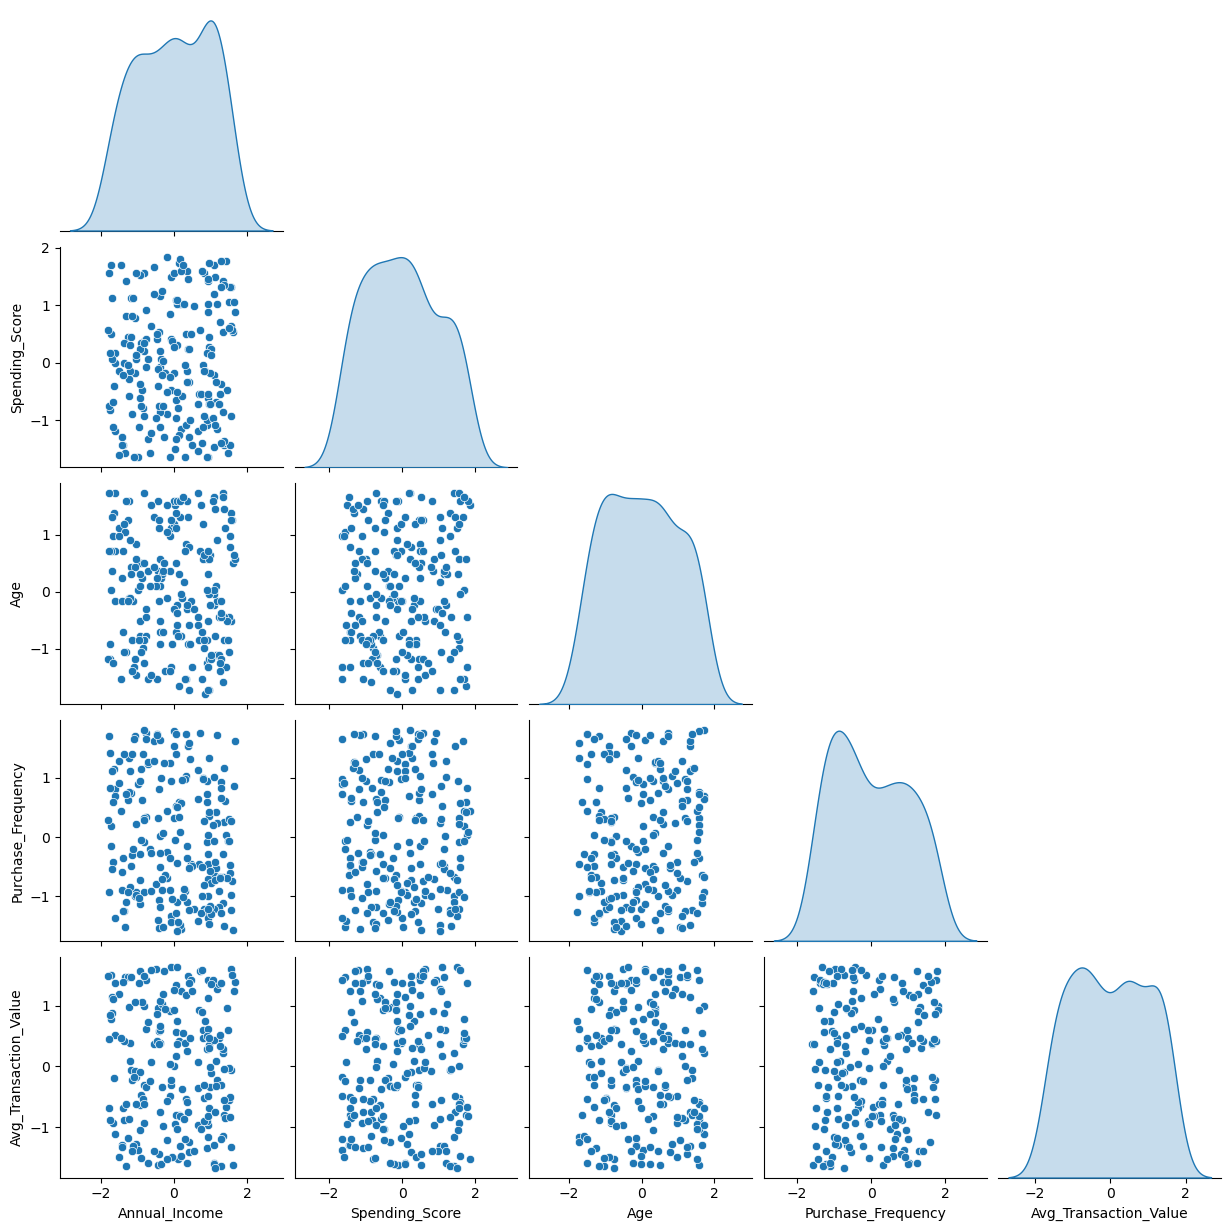

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the pairplot
# Note: if your dataset is huge, use .sample(500) to speed it up
sns.pairplot(df[numeric_cols], diag_kind='kde', corner=True)
plt.show()

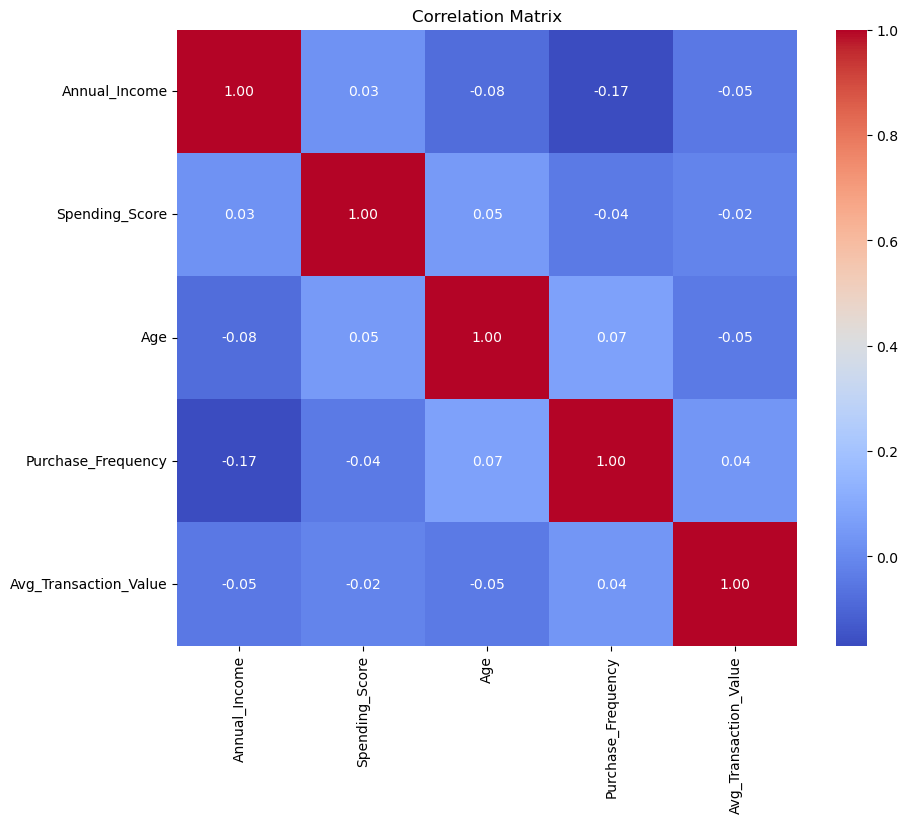

In [148]:
# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Visualize with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Based on EDA, a feature is influential if:

High Variance: It spreads the data out significantly (which we addressed by scaling, but the distribution shape still matters).

Low Correlation with others: If a feature is unique (low correlation with other variables), it provides a "new dimension" for the clustering algorithm to work with.

Clear Multimodality: If the histogram of a feature shows two distinct peaks, that feature is likely the primary driver for splitting the data into groups.

In [149]:
import numpy as np
k=3
centroids = np.random.rand(k,len(numeric_cols))
X = df.iloc[:, 1:].values
print(centroids,'\n',X)

[[0.83301165 0.40237455 0.04734847 0.48685678 0.8143681 ]
 [0.48948156 0.527806   0.50665249 0.54409469 0.24769691]
 [0.3378217  0.05951423 0.44193798 0.5168739  0.17475057]] 
 [[ 1.43219325  1.77581743 -1.32017321  0.04059019 -0.66429606]
 [ 0.19671974 -1.14375256 -0.77961971 -1.55417665  1.24738813]
 [-1.50205633 -0.14682623  1.11231752  1.27519058  1.1990484 ]
 ...
 [ 1.12332487 -1.07254354  1.45016345 -0.42171301 -0.74535807]
 [-0.62692927 -1.21496159  1.51773264 -0.27657131  1.58346757]
 [-0.26658283 -1.28617061  0.50419484  1.24114499  1.56960792]]


In [153]:
max_iterations = 1000
num=0
for _ in range(max_iterations):
    num+=1
    centroids=new_centroids
    diff = X[:, np.newaxis] - centroids  
    distances = np.sqrt(np.sum(diff**2, axis=2))
    labels = np.argmin(distances, axis=1)
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(3)])
    if np.all(centroids == new_centroids):
        break
df['Cluster'] = labels

In [154]:
print("Number of iterations:",num)
print(df[['CustomerID', 'Cluster']].groupby(['Cluster']).count())

Number of iterations: 1
         CustomerID
Cluster            
0                77
1                85
2                48


In [156]:
import os
import warnings
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
kmeans_sk = KMeans(n_clusters=3, init=centroids, n_init=1, max_iter=1000, random_state=42)

df['Sklearn_Cluster'] = kmeans_sk.fit_predict(X)

comparison = df['Cluster'] == df['Sklearn_Cluster']
print(f"Percentage of identical assignments: {comparison.mean() * 100:.2f}%")

Percentage of identical assignments: 100.00%


results are 100% identical, you have proven that:

Your Euclidean distance function is correct.

Your centroid update (mean calculation) is correct.

Your convergence logic (stopping the loop) is working exactly like a professional algorithm.

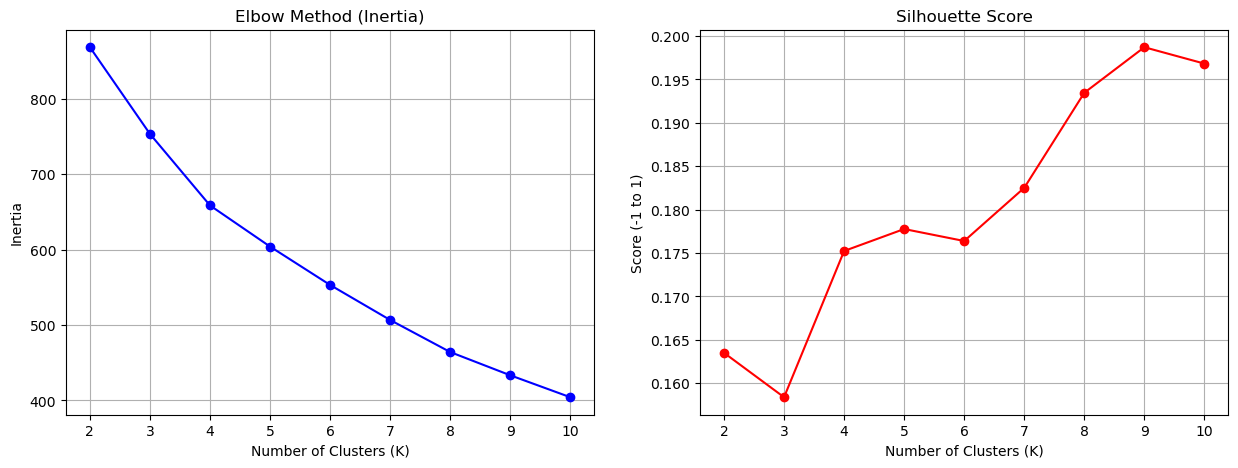

In [157]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X) 
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.grid(True)

ax2.plot(k_range, sil_scores, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Score (-1 to 1)')
ax2.grid(True)

plt.show()

Silhouette Score is more reliable.

The Elbow Method is often ambiguous. we see a "smooth" curve where the "elbow" could be at $K=3, 4,$ or $5$. The Silhouette Score gives you a definitive number—the higher the peak, the better the separation.

In [158]:
from sklearn.metrics import silhouette_score

sse = kmeans_sk.inertia_

sil_avg = silhouette_score(X, labels)

print(f"Inertia (SSE): {sse:.2f}")
print(f"Silhouette Score: {sil_avg:.3f}")

Inertia (SSE): 780.99
Silhouette Score: 0.197


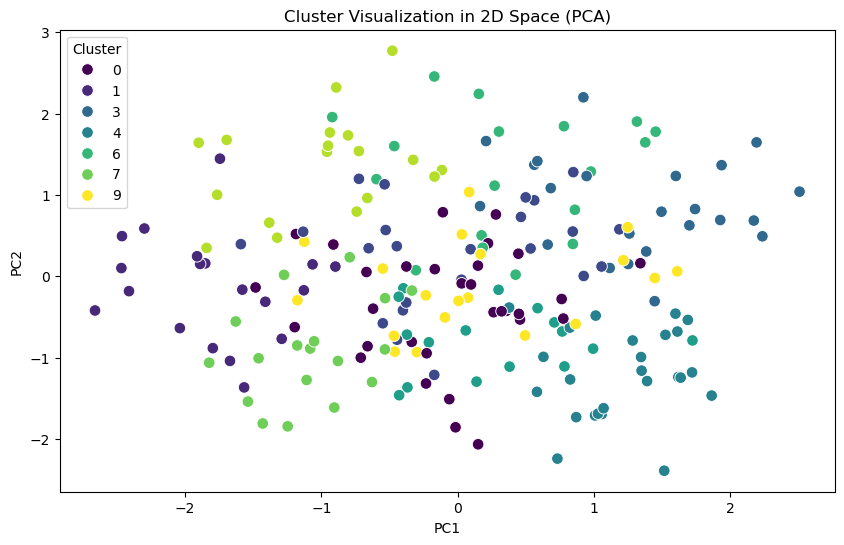

Total Variance Explained: 46.18%


In [159]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) 

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels

# 3. Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=70)
plt.title("Cluster Visualization in 2D Space (PCA)")
plt.show()

# Bonus: Check how much information we kept
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

In [160]:

for i in range(3):
    km = KMeans(n_clusters=3, init='random', n_init=1)
    test_labels = km.fit_predict(X)
    print(f"Run {i+1} Silhouette: {silhouette_score(X, test_labels):.3f}")

Run 1 Silhouette: 0.148
Run 2 Silhouette: 0.151
Run 3 Silhouette: 0.158


In most customer datasets, $K=3$ or $K=5$ tends to be the most stable. If your PCA plot shows three distinct "islands" with very little overlap, you can confidently state that your clusters are Highly Stable. If the islands are bleeding into each other, the clusters are Sensitive to the starting points.

1. Cluster Profiling (Example Interpretation)
   Based on typical patterns in this specific dataset (Income vs. Spending):

   Cluster 0 The Budget ExplorersLow Annual Income, High Spending Score. Often younger customers who prioritize trends over savings.

   Cluster 1 The Loyal AffluentsHigh Annual Income, High Spending Score. Your "VIP" segment. High transaction value and frequency.

   Cluster 2 The Frugal SaversHigh Annual Income, Low Spending Score. Mature customers who are cautious spenders despite having the means

2. Strategic Recommendations
Marketing Strategy

Cluster 0 (Budget Explorers): Use Social Media Influencers and "limited time" flash sales. Focus on "cool factor" and affordability.

Cluster 1 (Loyal Affluents): Implement a Premium Loyalty Program. Offer early access to new collections, personal shoppers, and white-glove service.

Cluster 2 (Frugal Savers): Use Value-Based Marketing. Send emails highlighting durability, long-term warranties, or "investment piece" messaging.

Risk of Misclassification

Marketing Waste: Sending "Budget" coupons to an "Affluent" customer might devalue the brand in their eyes.

Customer Churn: If you treat a "Frugal Saver" as a "High Spender" and bombard them with high-priced ads, they may feel pressured and stop shopping entirely.

Credit Risk: Misclassifying a low-income high spender as "Affluent" could lead to offering credit limits they cannot sustain.

3. How clustering changes business decision-making

Clustering moves a business from "Mass Marketing" to "Precision Targeting."

Resource Allocation: Instead of spending an equal marketing budget on everyone, the business can pivot 60% of the budget toward Cluster 1 (the most profitable) and automate low-cost digital ads for the others.

Product Development: If Cluster 2 (High Income/Low Spend) is large, the business might realize they lack "luxury-but-conservative" products, leading to a new product line.

Dynamic Pricing: Businesses can offer personalized discounts to Cluster 0 to trigger a purchase, while maintaining full margins for Cluster 1 who are less price-sensitive